# Training the CBOW

In [1]:
import numpy as np
from utils2 import get_dict

## Forward propagation

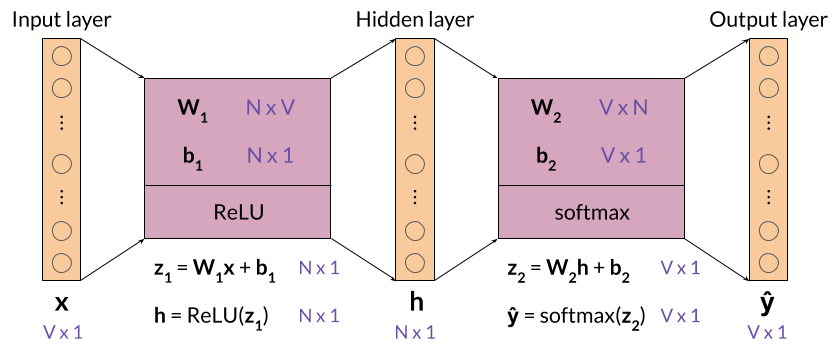

In [2]:
N = 3 # Hyperparameter of the CBOW model that represent the size of the word embedding vectors, as well as the size of the hidden layer

V = 5 # Size of vocabulary in previous lecture notebooks

### Initialization of weights and biases

In [3]:
# Define first matrix of weights
W1 = np.array([[ 0.41687358,  0.08854191, -0.23495225,  0.28320538,  0.41800106],
               [ 0.32735501,  0.22795148, -0.23951958,  0.4117634 , -0.23924344],
               [ 0.26637602, -0.23846886, -0.37770863, -0.11399446,  0.34008124]])

# Define second matrix of weights
W2 = np.array([[-0.22182064, -0.43008631,  0.13310965],
               [ 0.08476603,  0.08123194,  0.1772054 ],
               [ 0.1871551 , -0.06107263, -0.1790735 ],
               [ 0.07055222, -0.02015138,  0.36107434],
               [ 0.33480474, -0.39423389, -0.43959196]])

# Define first vector of biases
b1 = np.array([[ 0.09688219],
               [ 0.29239497],
               [-0.27364426]])

# Define second vector of biases
b2 = np.array([[ 0.0352008 ],
               [-0.36393384],
               [-0.12775555],
               [-0.34802326],
               [-0.07017815]])

In [4]:
print(f'V (vocabulary size): {V}')
print(f'N (embedding size / size of the hidden layer): {N}')
print(f'size of W1: {W1.shape} (NxV)')
print(f'size of b1: {b1.shape} (Nx1)')
print(f'size of W2: {W2.shape} (VxN)')
print(f'size of b2: {b2.shape} (Vx1)')

V (vocabulary size): 5
N (embedding size / size of the hidden layer): 3
size of W1: (3, 5) (NxV)
size of b1: (3, 1) (Nx1)
size of W2: (5, 3) (VxN)
size of b2: (5, 1) (Vx1)


In [5]:
# Define the tokenized version of the corpus
words = ['i', 'am', 'happy', 'because', 'i', 'am', 'learning']

# Get 'word2Ind' and 'Ind2Word' dictionaries for the tokenized corpus
word2Ind, Ind2word = get_dict(words)

# Define the 'get_windows' function as seen in a previous notebook
def get_windows(words,C):
    i = C
    while i < len (words) - C:
        center_word = words[i]
        context_words = words[(i - C):i] + words[(i+1):(i+C+1)]
        yield context_words, center_word
        i += 1

# Define the 'word_to_one_hot_vector' function
def word_to_one_hot_vector (word, word2Ind, V):
    one_hot_vector = np.zeros(V)
    one_hot_vector[word2Ind[word]] = 1
    return one_hot_vector

# Define the 'context_words_to_vector' function 
def context_words_to_vector(context_words, word2Ind, V):
    context_words_vectors = [word_to_one_hot_vector(w, word2Ind, V) for w in context_words]
    context_words_vectors = np.mean(context_words_vectors, axis = 0)
    return context_words_vectors

# Define the generator function 'get_training_example'
def get_training_example(words, C, word2Ind, V):
    for context_words, center_word in get_windows(words, C):
        yield context_words_to_vector(context_words, word2Ind, V), word_to_one_hot_vector(center_word, word2Ind, V)
        


### Training example

In [6]:
training_examples = get_training_example(words, 2, word2Ind, V)

In [7]:
x_array, y_array = next(training_examples)

"""
next is another special keyword, which gets the next available value from an iterator. Here, you'll get the very first value, which is the first training example. If you run this cell again, you'll get the next value, and so on until the iterator runs out of values to return.

In this notebook next is used because you will only be performing one iteration of training
"""

"\nnext is another special keyword, which gets the next available value from an iterator. Here, you'll get the very first value, which is the first training example. If you run this cell again, you'll get the next value, and so on until the iterator runs out of values to return.\n\nIn this notebook next is used because you will only be performing one iteration of training\n"

In [8]:
# Context words vector
x_array

array([0.25, 0.25, 0.  , 0.5 , 0.  ])

In [9]:
# One hot vector of center word
y_array

array([0., 0., 1., 0., 0.])

In [10]:
# Convert vectors into matrices (2D arrays)
x = x_array.copy()

# Reshape x
x.shape = (V,1)

print (f'x:\n{x}\n')

y = y_array.copy()

print (f'x:\n{y}\n')

x:
[[0.25]
 [0.25]
 [0.  ]
 [0.5 ]
 [0.  ]]

x:
[0. 0. 1. 0. 0.]



In [11]:
# Define 'relu'
def relu (z):
    result = z.copy()
    result[result < 0] =  0
    return result

# Define 'softmax'
def softmax(z):
    e_z = np.exp(z)
    sum_e_z = np.sum(e_z)
    return e_z/sum_e_z

### Values of the hidden layer

In [12]:
# z1 is the values of the first hidden layer before applying the ReLU function

z1 = np.dot(W1, x) + b1
z1

array([[ 0.36483875],
       [ 0.63710329],
       [-0.3236647 ]])

In [13]:
# compute h (z1 after applying the ReLU function)
h = relu(z1)

h

array([[0.36483875],
       [0.63710329],
       [0.        ]])

### Values of the output layer

In [14]:
# z2 is the values of the output layer before applying the softmax function

z2 = np.dot(W2, h) + b2
z2

array([[-0.31973737],
       [-0.28125477],
       [-0.09838369],
       [-0.33512159],
       [-0.19919612]])

In [15]:
# compute y_hat (z2 after applying the softmax function)

y_hat = softmax(z2)
y_hat

array([[0.18519074],
       [0.19245626],
       [0.23107446],
       [0.18236353],
       [0.20891502]])

## Cross-entropy loss

In [16]:
y_hat

array([[0.18519074],
       [0.19245626],
       [0.23107446],
       [0.18236353],
       [0.20891502]])

In [17]:
y

array([0., 0., 1., 0., 0.])

In [ ]:
def cross_entropy_loss(y_predicted, y_actual):
    # Fill the loss variable with your code
    loss = None
    return loss